#### 이자율변수만으로_분류모델 실험 251031

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns 
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv("./credit_risk_dataset.csv") 
df.head() 

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [3]:
X = df['loan_int_rate']
y = df['loan_grade']

In [4]:
X.isnull().sum()

3116

In [5]:
X = X.fillna(0)

In [6]:
# 트레이닝/테스트 데이터 분할 
from sklearn.model_selection import train_test_split
X_tn, X_te, y_tn, y_te = train_test_split(X, y, random_state=0, stratify=y)

In [7]:
print(X_tn.shape)
print(X_te.shape)

(24435,)
(8146,)


In [8]:
print(y_tn.value_counts())

loan_grade
A    8083
B    7838
C    4843
D    2719
E     723
F     181
G      48
Name: count, dtype: int64


In [9]:
print(y_te.value_counts())

loan_grade
A    2694
B    2613
C    1615
D     907
E     241
F      60
G      16
Name: count, dtype: int64


<Axes: xlabel='loan_int_rate', ylabel='Count'>

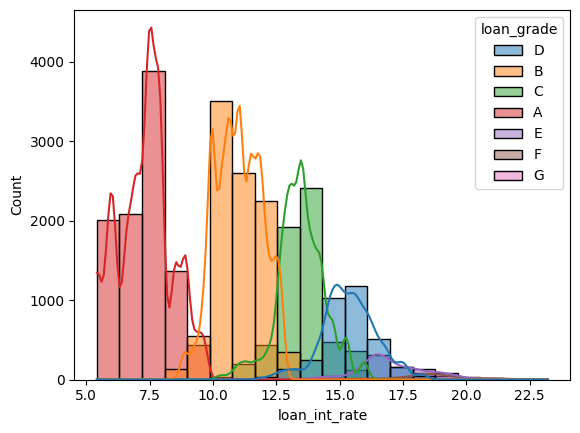

In [10]:
sns.histplot(data=df, x='loan_int_rate', hue='loan_grade', bins=20, kde=True, color='cornflowerblue')

#### 로지스틱 모델 돌려보기 

In [11]:
# 로지스틱 회귀분석
from sklearn.linear_model import LogisticRegression
clf_logi = LogisticRegression()
clf_logi.fit(pd.DataFrame(X_tn), y_tn)

LogisticRegression()

In [19]:
# 예측
pred_logistic = clf_logi.predict(pd.DataFrame(X_te))
print(pred_logistic)

['B' 'D' 'A' ... 'C' 'B' 'A']


In [20]:
# confusion matrix 확인
from sklearn.metrics import confusion_matrix
conf_matrix = confusion_matrix(y_te, pred_logistic)
print(conf_matrix)

[[2387  307    0    0    0    0    0]
 [ 250 2363    0    0    0    0    0]
 [ 159  349 1015   92    0    0    0]
 [  75   25  335  471    1    0    0]
 [  26    0   20  163   32    0    0]
 [   5    0    1   21   33    0    0]
 [   2    0    0    1   13    0    0]]


In [21]:
# 분류 레포트 확인
from sklearn.metrics import classification_report
class_report = classification_report(y_te, pred_logistic)
print(class_report)

              precision    recall  f1-score   support

           A       0.82      0.89      0.85      2694
           B       0.78      0.90      0.84      2613
           C       0.74      0.63      0.68      1615
           D       0.63      0.52      0.57       907
           E       0.41      0.13      0.20       241
           F       0.00      0.00      0.00        60
           G       0.00      0.00      0.00        16

    accuracy                           0.77      8146
   macro avg       0.48      0.44      0.45      8146
weighted avg       0.75      0.77      0.75      8146

